In [ ]:
#EJERCICIO 1: K MEANS SEGUROS

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("E:\Documentos 2\ML y DL\insurance.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USER\AppData\Local\Temp\ipykernel_23376\2462803096.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\Documentos 2\ML y DL\insurance.csv")


In [6]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
print(f"\nFilas: {df.shape[0]}, columnas: {df.shape[1]}")


Filas: 1338, columnas: 7


In [8]:
#variables para analizar y pues segmentar/clusterizar
X = df[["age", "bmi", "children", "charges"]]

In [9]:
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

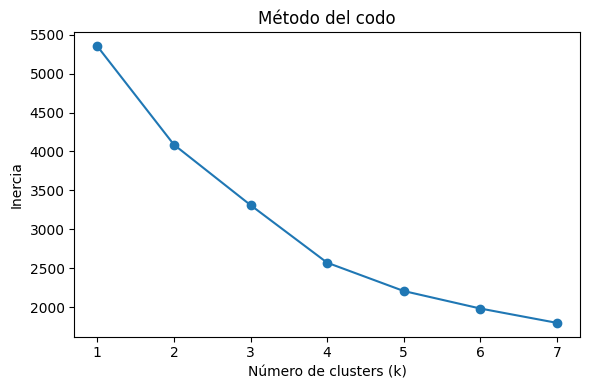

In [12]:
#metodo del codo (explicar a detalle este pedo)
inercias = []
rango_k = range(1, 8)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(rango_k), inercias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.tight_layout()
plt.show()

In [13]:
#entrenando con 3 clustersillos
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
#descriptivos bien basic por clusterrr
print("\nPromedios por cluster:")
print(df.groupby("cluster")[["age", "bmi", "children", "charges"]].mean().round(1))

print("\nProporción de fumadores por cluster:")
print(df.groupby("cluster")["smoker"].value_counts(normalize=True).round(2))


Promedios por cluster:
          age   bmi  children  charges
cluster                               
0        51.2  31.1       1.2  12632.0
1        39.8  35.3       1.1  40712.7
2        27.0  29.0       1.0   6374.7

Proporción de fumadores por cluster:
cluster  smoker
0        no        0.90
         yes       0.10
1        yes       0.93
         no        0.07
2        no        0.89
         yes       0.11
Name: proportion, dtype: float64


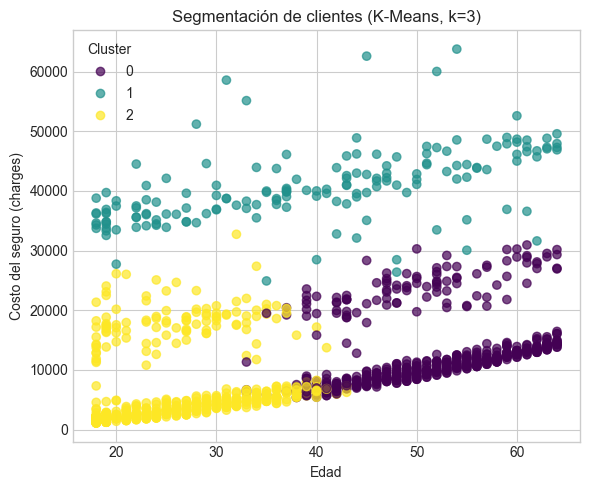

In [18]:
#grafico chulo
plt.figure(figsize=(6, 5))
scatter = plt.scatter(df["age"], df["charges"], c=df["cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("Edad")
plt.ylabel("Costo del seguro (charges)")
plt.title("Segmentación de clientes (K-Means, k=3)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
#pa explicar la proporcion de cada cluster
for cluster_id in sorted(df["cluster"].unique()):
    grupo = df[df["cluster"] == cluster_id]
    edad_prom = grupo["age"].mean()
    bmi_prom = grupo["bmi"].mean()
    hijos_prom = grupo["children"].mean()
    costo_prom = grupo["charges"].mean()
    pct_fumadores = (grupo["smoker"] == "yes").mean() * 100
    n = len(grupo)

    print(f"Cluster {cluster_id} ({n} clientes, {n/len(df)*100:.0f}% del total)")
    print(f"  Edad promedio: {edad_prom:.0f} años")
    print(f"  BMI promedio: {bmi_prom:.1f}")
    print(f"  Hijos promedio: {hijos_prom:.1f}")
    print(f"  % fumadores: {pct_fumadores:.0f}%")
    print(f"  Costo promedio del seguro: ${costo_prom:,.0f}")
    print()

Cluster 0 (591 clientes, 44% del total)
  Edad promedio: 51 años
  BMI promedio: 31.1
  Hijos promedio: 1.2
  % fumadores: 10%
  Costo promedio del seguro: $12,632

Cluster 1 (161 clientes, 12% del total)
  Edad promedio: 40 años
  BMI promedio: 35.3
  Hijos promedio: 1.1
  % fumadores: 93%
  Costo promedio del seguro: $40,713

Cluster 2 (586 clientes, 44% del total)
  Edad promedio: 27 años
  BMI promedio: 29.0
  Hijos promedio: 1.0
  % fumadores: 11%
  Costo promedio del seguro: $6,375

